In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import warnings

df = pd.read_csv('insurance.csv')

## EDA
df.isnull().sum() - check null values in each column

df.shape                        --- tells dimension of dataset

df.info()                       --- tells data abt the columns

df.describe()                   --- tells stats about the cols

In [2]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
df.isnull().sum()       #check for null values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

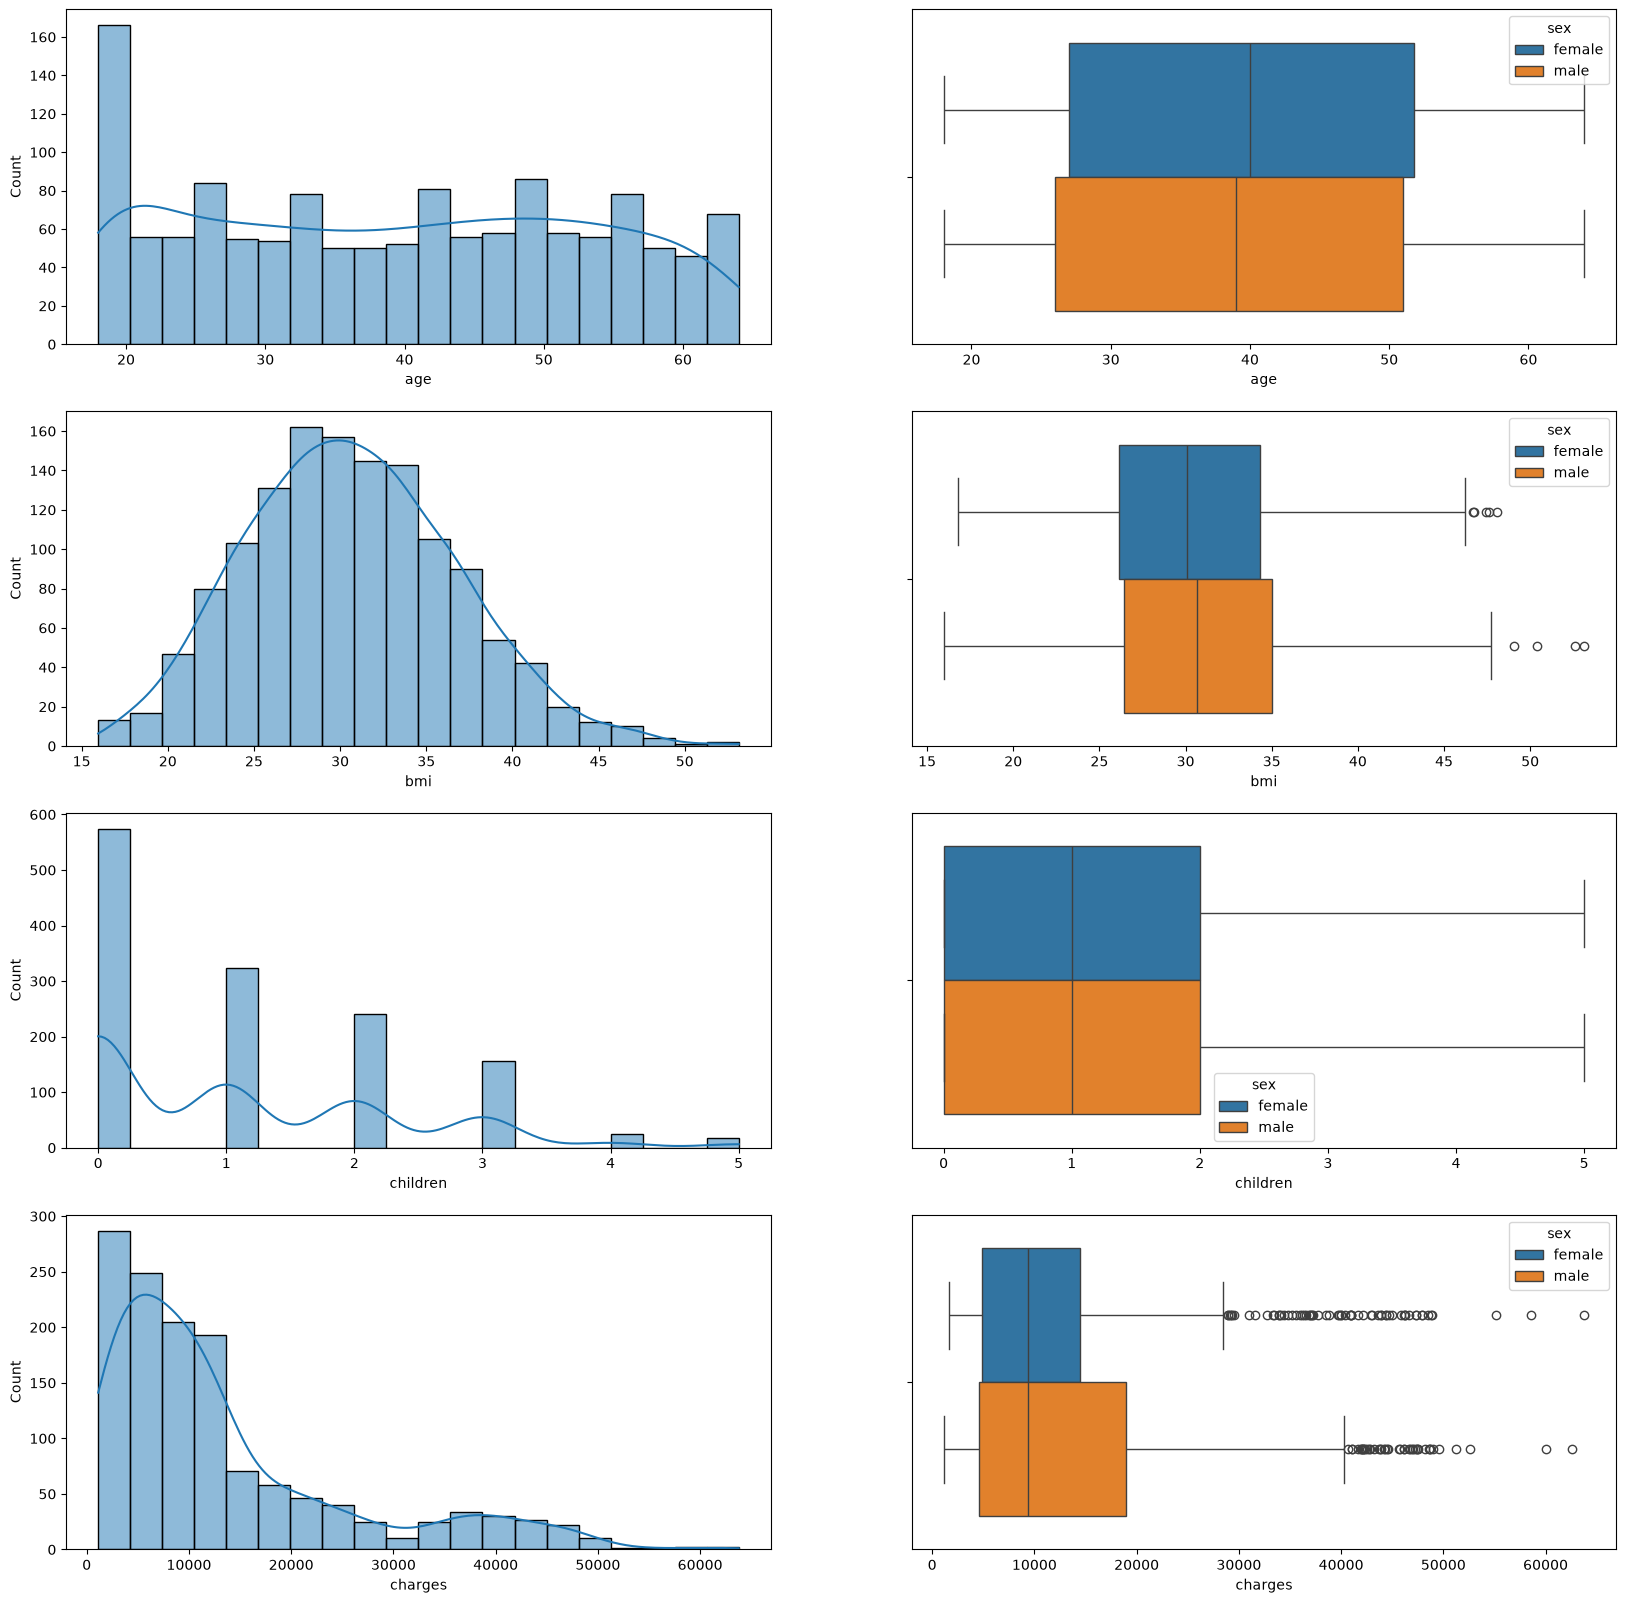

In [4]:
num_cols = ['age', 'bmi', 'children', 'charges']
i = 1
plt.figure(figsize=(20,20))
for col in num_cols:
    plt.subplot(4,2,i)
    sb.histplot(df[col], kde = True, bins=20)
    i += 1
    plt.subplot(4,2,i)
    sb.boxplot(x=df[col],hue=df['sex'])
    i += 1

C:\Users\prajj\AppData\Local\Temp\ipykernel_11896\1154787379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=col, data=df, palette='rainbow')
C:\Users\prajj\AppData\Local\Temp\ipykernel_11896\1154787379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=col, data=df, palette='rainbow')
C:\Users\prajj\AppData\Local\Temp\ipykernel_11896\1154787379.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=col, data=df, palette='rainbow')


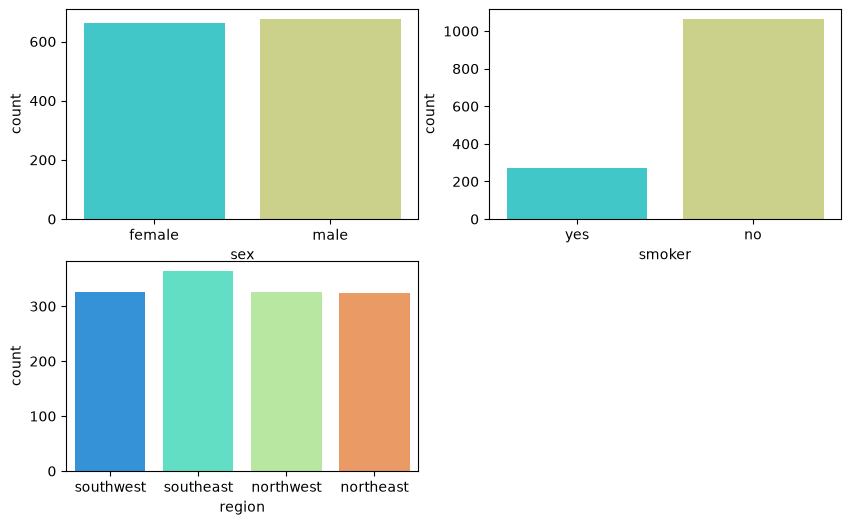

In [5]:
categ_cols = ['sex', 'smoker', 'region']
i = 1
plt.figure(figsize=(10,6))
for col in categ_cols:
    plt.subplot(2,2,i)
    sb.countplot(x=col, data=df, palette='rainbow')
    i += 1

<Axes: >

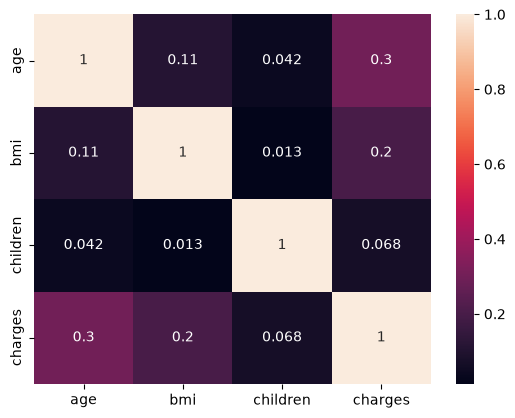

In [6]:
# HEATMAP FOR CORRELATION -- NUMERIC ONLY
sb.heatmap(df.corr(numeric_only=True), annot=True)

### DATA CLEANING AND PREPROCESSING
##### handle Null values, duplicates
- isnull()                                  --                    --- for checking Null values
- drop_duplicates(inplace=true)             --                    --- removing duplicated rows
- df['col'] = df['col'].map({dictionary_to_map_val})    --        --- to label encoding

- pd.get_dummies(df, columns = [c1, c2], dropfirst = true)        --- to one hot encode , dropfirst removes one type, making it the obvios choice. If not all other, then the exculed one is the type
- df.astype(int)                                                 --- code in from of 0,1

In [7]:
# No null values in current dataset
# Duplicate removal

df.drop_duplicates(inplace=True)

# renaming
df.rename(columns={
    'sex' : 'isMale',
    'smoker' : 'isSmoker',
}, inplace=True)

# label encoding 
df['isMale']       = df['isMale'].map({'male': 1, 'female': 0})
df['isSmoker']    = df['isSmoker'].map({"yes": 1, "no": 0})

In [8]:
# ONE HOT ENCODING
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df = df.astype(int)
df.head()

,age,isMale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27,0,1,16884,0,0,1
1,18,1,33,1,0,1725,0,1,0
2,28,1,33,3,0,4449,0,1,0
3,33,1,22,0,0,21984,1,0,0
4,32,1,28,0,0,3866,1,0,0


# Fature Engineering & Extraction
usually done on input variables only.
we try to convert all values as numeric..beter if between -1 to 1...best if binary
##### creating col for subdivisions of a col
- create bins using cut functions
- classify bins and add labels
## Feature Scaling
needed for models which get affected by weights, ex: linear reg, logistic reg, etc

- StandardScaler() --- -- -- Standardization pupose
- StandardScaler().fit_transform(data) ---- -- - transform to standardized data 
## Feature Extraction
Done to select some features 
- from scipy.stats import pearsonr -- to check correlation against target,( here charges)
- values of corr = -1 to 1, higher extereme values are said to be more correlated

In [9]:
# subdividing and adding cols acc to BMI
df['body_category'] = pd.cut(
    df['bmi'],
    bins = [0, 18.5, 24.9, 29.9, float('inf')], 
    labels= ['underweight', 'normal', 'overweight', 'obese']
)
df.head()


,age,isMale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,body_category
0,19,0,27,0,1,16884,0,0,1,overweight
1,18,1,33,1,0,1725,0,1,0,obese
2,28,1,33,3,0,4449,0,1,0,obese
3,33,1,22,0,0,21984,1,0,0,normal
4,32,1,28,0,0,3866,1,0,0,overweight


In [10]:
# one hot encoding on body category
df = pd.get_dummies(df, columns=['body_category'], drop_first=False)
df = df.astype(int)
df.head()

,age,isMale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,body_category_underweight,body_category_normal,body_category_overweight,body_category_obese
0,19,0,27,0,1,16884,0,0,1,0,0,1,0
1,18,1,33,1,0,1725,0,1,0,0,0,0,1
2,28,1,33,3,0,4449,0,1,0,0,0,0,1
3,33,1,22,0,0,21984,1,0,0,0,1,0,0
4,32,1,28,0,0,3866,1,0,0,0,0,1,0


In [11]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler
std_cols = ['age', 'bmi', 'children']
df[std_cols] = StandardScaler().fit_transform(df[std_cols])    #using STANDARDSCALAR CLASS & ITS METHOD
df 

,age,isMale,bmi,children,isSmoker,charges,region_northwest,region_southeast,region_southwest,body_category_underweight,body_category_normal,body_category_overweight,body_category_obese
0,-1.440418,0,-0.517949,-0.909234,1,16884,0,0,1,0,0,1,0
1,-1.511647,1,0.462463,-0.079442,0,1725,0,1,0,0,0,0,1
2,-0.799350,1,0.462463,1.580143,0,4449,0,1,0,0,0,0,1
3,-0.443201,1,-1.334960,-0.909234,0,21984,1,0,0,0,1,0,0
4,-0.514431,1,-0.354547,-0.909234,0,3866,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,1,-0.027743,1.580143,0,10600,1,0,0,0,0,0,1
1334,-1.511647,0,0.135659,-0.909234,0,2205,0,0,0,0,0,0,1
1335,-1.511647,0,0.952670,-0.909234,0,1629,0,1,0,0,0,0,1
1336,-1.297958,0,-0.844753,-0.909234,0,2007,0,0,1,0,0,1,0


In [12]:
# Feature Extraction

from scipy.stats import pearsonr     # to check correlation against target, here charges
selected_features = [
    'age', 'bmi', 'children', 'isMale', 'isSmoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'body_category_normal', 'body_category_overweight', 'body_category_obese'
]
# create a dictionary of correlations against charges
correlations = {
    feature: pearsonr(df[feature], df['charges'])[0]
    for feature in selected_features
}

#store the correlation dict in a dataframe
correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
4,isSmoker,0.787234
0,age,0.298309
10,body_category_obese,0.200348
1,bmi,0.196236
6,region_southeast,0.073577
2,children,0.067390
3,isMale,0.058046
5,region_northwest,-0.038695
7,region_southwest,-0.043637
8,body_category_normal,-0.104042


In [17]:
cat_features = [
    'isMale', 'isSmoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'body_category_normal', 'body_category_overweight', 'body_category_obese'
]

In [18]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df['charges_bin'] = pd.qcut(df['charges'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df[col], df['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
isSmoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
isMale,10.258784,0.01649,Reject Null (Keep Feature)
body_category_obese,8.515711,0.036473,Reject Null (Keep Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
body_category_overweight,4.25149,0.235557,Accept Null (Drop Feature)
body_category_normal,3.708088,0.29476,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [1]:
final_df = df[['age', 'isMale', 'bmi', 'children', 'isSmoker', 'charges','region_southeast','body_category_obese']]

NameError: name 'df' is not defined